In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.special import logit

In [20]:
import sys
import os
sys.path.append(os.path.abspath('/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation'))

from src.dgp import SpikedIsotropic
from src.algorithms import SelfTrainedGradientDescent
from src.callbacks import TestEvaluatorCallback

from scripts.runner import MonteCarloExperiment

In [21]:
#np.seterr(all='raise')

np.seterr(divide='ignore', over='ignore', under='ignore', invalid='ignore') # Suppress the Apple glitch
# The RuntimeWarning: divide by zero encountered in matmul error is a known Apple Accelerate and NumPy bug affecting Mac devices with M4 chips running macOS Sequoia. 



{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [22]:
d = 500
p = 0.5
mu = np.zeros(d)
mu[0:5] = 0.5 
sigma = 1.0
seed = 42

data = SpikedIsotropic(d=d, mu=mu, sigma=sigma, p=p, seed=seed)

In [23]:
N = 100
M = 10000
N_test = 5000

X_lab, Y_lab, X_unl, Y_unl, X_test, Y_test = data.sample(N=N, M=M, N_test=N_test)

In [ ]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    metrics={
        "lab_error", "unl_error", "test_error", 
        "unl_flipping_rate", "unl_usage", "unl_flipping_rate"
    }
)

base_params = {
    "n_iterations": 1000, # T
    "ramp_start": 250, # T0
    "ramp_end": 300, # T1
    "margin_threshold": logit(0.75), # kappa
    "penalty_param": 0.1, # lambda
    "step_size": 0.1, # eta
    "pseudo_label_param": 0.5 # alpha
}


st = SelfTrainedGradientDescent(**base_params, callback=callback)

w = st.fit(X_lab, Y_lab, X_unl)

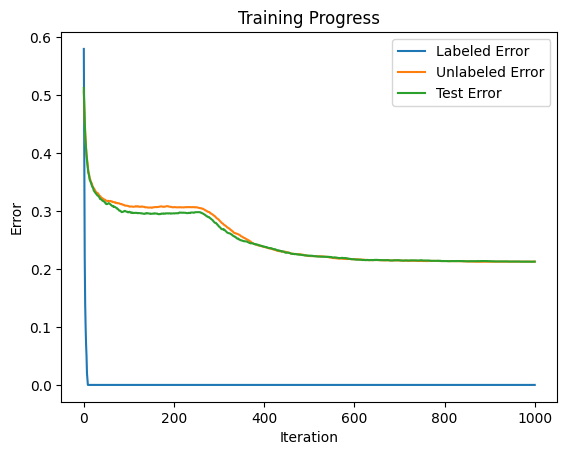

In [227]:
plt.plot(callback.history_["lab_error"], label='Labeled Error')
plt.plot(callback.history_["unl_error"], label='Unlabeled Error')
plt.plot(callback.history_["test_error"], label='Test Error')

plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Training Progress')
plt.legend()
plt.show()

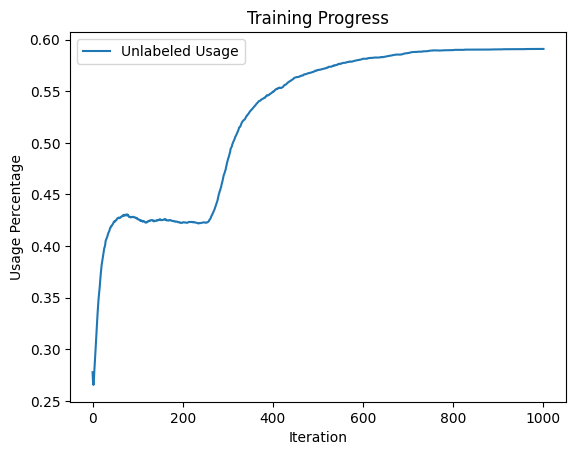

In [228]:
plt.plot(callback.history_["unl_usage"], label='Unlabeled Usage')

plt.xlabel('Iteration')
plt.ylabel('Usage Percentage')
plt.title('Training Progress')
plt.legend()
plt.show()

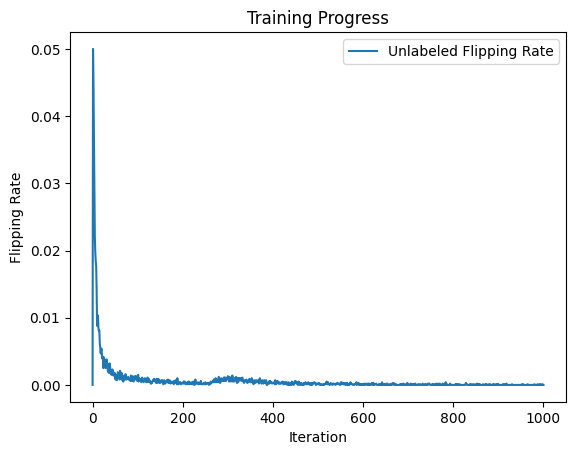

In [229]:
plt.plot(callback.history_["unl_flipping_rate"], label='Unlabeled Flipping Rate')

plt.xlabel('Iteration')
plt.ylabel('Flipping Rate')
plt.title('Training Progress')
plt.legend()
plt.show()

In [238]:
runs = 10
monte_carlo_seeds = list(range(runs))
T = 500
N = 100
M = 10000
N_test = 5000

mc = MonteCarloExperiment(
    data_gen=data, algorithm=SelfTrainedGradientDescent, 
    N=N, M=M, N_test=N_test, T=T, 
    base_params=base_params
)

In [239]:
target_param = 'margin_threshold'
test_values = [logit(v) for v in [0.6, 0.75, 0.9, 0.95]]

mc.run_sweep(
    seeds=monte_carlo_seeds, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values
)

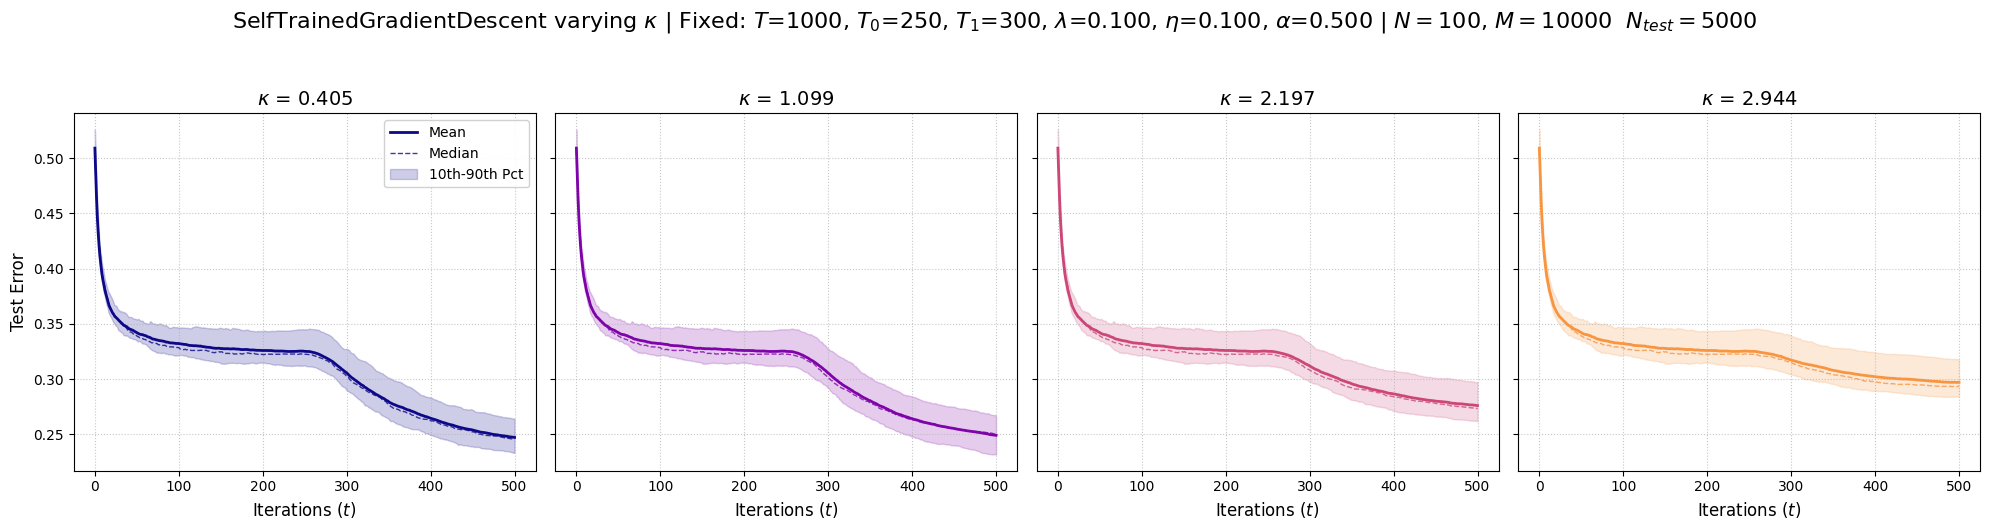

In [240]:
mc.plot_trajectories(metric='test_error')